# Bayesian Inference for Systems of Elementary Reactions

## Import Libraries

In [1]:
from pathlib import Path
import importlib
import json
import arviz as az
import matplotlib.pyplot as plt

from experiment_framework import load_experiment_bundle
import inference_plotting as inference_plotting_module
import inference_runner as inference_runner_module
importlib.reload(inference_plotting_module)
importlib.reload(inference_runner_module)
from inference_runner import (
    get_free_parameter_names,
    plot_parameter_marginals,
    plot_posterior_trace_diagnostics,
    plot_predictive,
    plot_priors,
    run_bayesian_inference,
    summarize_inference_metrics,
 )
from reaction_model_builder import build_ode_system_from_reactions

## Run Bayesian Analysis and Plot Diagnostics

Toggle workflow mode on to load inference data and skip to plotting

In [5]:
name = "Both"

# Toggle workflow mode:
use_existing_results = True
use_log_param_axis = True

# Plot styling
plt.style.use("default")
posterior_plot_color = "C0"
observed_plot_color = "C1"

# Paths for model config + inference artifacts
reactions_source = "./Simplified_FAS/Reactions"
savedir = "./Simplified_FAS/Results"
solver_params_file = f"solver_params_{name}.json"
prior_samples_file = f"{name}_prior_samples_pm.nc"
posterior_samples_file = f"{name}_posterior_samples_pm.nc"
trace_plot_file = f"{name}_trace_plot.png"

solver_params_candidates = [
    (Path(savedir) / solver_params_file).expanduser().resolve(),
    Path("./Simplified_FAS") / solver_params_file,
 ]
written_solver_params_path = next(
    (path.resolve() for path in solver_params_candidates if path.exists()),
    None,
 )
if written_solver_params_path is None:
    raise FileNotFoundError(
        "Solver params file not found. Expected one of: "
        f"{solver_params_candidates[0].resolve()} or {solver_params_candidates[1].resolve()}"
    )

with open(written_solver_params_path, "r", encoding="utf-8") as solver_file:
    solver_params = json.load(solver_file)

prior_file_path = Path(savedir) / prior_samples_file
posterior_file_path = Path(savedir) / posterior_samples_file
trace_path = Path(savedir) / trace_plot_file
parameter_density_path = trace_path.with_name(f"{trace_path.stem}_hist.pdf")
prior_density_path = trace_path.with_name(f"{trace_path.stem}_prior_hist.pdf")

if not use_existing_results:
    result = run_bayesian_inference(
        solver_params_file=str(written_solver_params_path),
        reactions_source=reactions_source,
        savedir=savedir,
        prior_samples_file=prior_samples_file,
        posterior_samples_file=posterior_samples_file,
        make_trace_plot=False,
        trace_plot_file=trace_plot_file,
        use_log_param_axis=use_log_param_axis,
    )

    inference_data = result.posterior
    experiment_for_plots = result.experiment
    free_params = result.free_params
    summary_table = result.summary
    loo_result = result.loo
    waic_result = result.waic

    experiment_summary_text = result.experiment_summary
    prior_path_text = result.prior_file
    results_path_text = result.results_file
    trace_path_text = str(trace_path)
    parameter_density_path_text = str(parameter_density_path)
    prior_density_path_text = str(prior_density_path)
else:
    if not posterior_file_path.exists():
        raise FileNotFoundError(
            f"Posterior samples file not found: {posterior_file_path}. Set use_existing_results=False to run inference first."
        )

    inference_data = az.from_netcdf(posterior_file_path)

    _, species_names_for_experiment, _, _ = build_ode_system_from_reactions(reactions_source)
    experiment_for_plots = load_experiment_bundle(
        solver_params=solver_params,
        solver_params_file=str(written_solver_params_path),
        species_names=species_names_for_experiment,
    )

    free_params = get_free_parameter_names(solver_params)
    metrics = summarize_inference_metrics(inference_data, free_params)
    free_params = metrics["free_params"]
    summary_table = metrics["summary"]
    loo_result = metrics["loo"]
    waic_result = metrics["waic"]

    experiment_summary_text = "Loaded existing posterior samples (inference run skipped)."
    prior_path_text = str(prior_file_path) if prior_file_path.exists() else "Not found"
    results_path_text = str(posterior_file_path)
    trace_path_text = str(trace_path)
    parameter_density_path_text = str(parameter_density_path)
    prior_density_path_text = str(prior_density_path)

print(experiment_summary_text)
print(f"\nPrior samples: {prior_path_text}")
print(f"\nPosterior samples: {results_path_text}")

display(summary_table)

print("\nModel comparison metrics:")
print("LOO:")
print(loo_result)
print("\nWAIC:")
print(waic_result)

trace_artifacts = plot_posterior_trace_diagnostics(
    inf_data=inference_data,
    free_params=free_params,
    save_file=trace_path_text,
    show=True,
    use_log_param_axis=use_log_param_axis,
 )
parameter_marginal_artifacts = plot_parameter_marginals(
    inf_data=inference_data,
    free_params=free_params,
    save_file=parameter_density_path_text,
    show=True,
    use_log_param_axis=use_log_param_axis,
 )
prior_marginal_artifacts = plot_priors(
    inf_data=inference_data,
    free_params=free_params,
    save_file=prior_density_path_text,
    show=True,
    use_log_param_axis=use_log_param_axis,
 )
predictive_artifacts = plot_predictive(
    inf_data=inference_data,
    experiment=experiment_for_plots,
    save_dir=str(trace_path.parent),
    file_stem=str(trace_path.stem),
    show=True,
    posterior_color=posterior_plot_color,
    observed_color=observed_plot_color,
 )

if trace_artifacts.get("plot_file"):
    print(f"\nSaved posterior trace diagnostics plot: {trace_artifacts['plot_file']}")
if parameter_marginal_artifacts.get("plot_file"):
    print(
        f"\nSaved posterior parameter marginal plot: "
        f"{parameter_marginal_artifacts['plot_file']}"
    )
if prior_marginal_artifacts.get("plot_file"):
    print(f"\nSaved prior parameter marginal plot: {prior_marginal_artifacts['plot_file']}")
elif not prior_marginal_artifacts.get("prior_var_names"):
    print("\nNo matching prior variables found for plotting.")

if predictive_artifacts.get("data_vs_results_plot_files"):
    print("\nSaved predictive plots:")
    for dataset_name, plot_path in predictive_artifacts["data_vs_results_plot_files"].items():
        print(f"  {dataset_name}: {plot_path}")

plot_artifacts = {
    "trace_diagnostics": trace_artifacts,
    "parameter_marginals": parameter_marginal_artifacts,
    "prior_marginals": prior_marginal_artifacts,
    "predictive": predictive_artifacts,
}

Sampling: [k2_1f, k2_3f]
/Users/annettethompson/anaconda3/envs/Bayesian/lib/python3.13/site-packages/pytensor/link/numba/dispatch/basic.py:211: UserWarning: Numba will use object mode to run SolOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/Users/annettethompson/anaconda3/envs/Bayesian/lib/python3.13/site-packages/pytensor/link/numba/dispatch/basic.py:211: UserWarning: Numba will use object mode to run VJPSolOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/Users/annettethompson/anaconda3/envs/Bayesian/lib/python3.13/site-packages/pytensor/link/numba/dispatch/basic.py:211: UserWarning: Numba will use object mode to run SolOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,411,0,0.89,3
,426,0,0.88,7
,391,0,1.06,3
,413,0,0.86,1


/Users/annettethompson/anaconda3/envs/Bayesian/lib/python3.13/site-packages/arviz/data/base.py:272: UserWarning: More chains (4) than draws (0). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


IndexError: list index out of range

/var/folders/41/tc0sn5mn46g26bhzv3slfbd80000gn/T/ipykernel_88811/2421118681.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.round(ax.get_xticks(),2), fontsize=18)


[Text(-5.0, 0, '-5.0'),
 Text(0.0, 0, '0.0'),
 Text(5.0, 0, '5.0'),
 Text(10.0, 0, '10.0'),
 Text(15.0, 0, '15.0'),
 Text(20.0, 0, '20.0'),
 Text(25.0, 0, '25.0')]

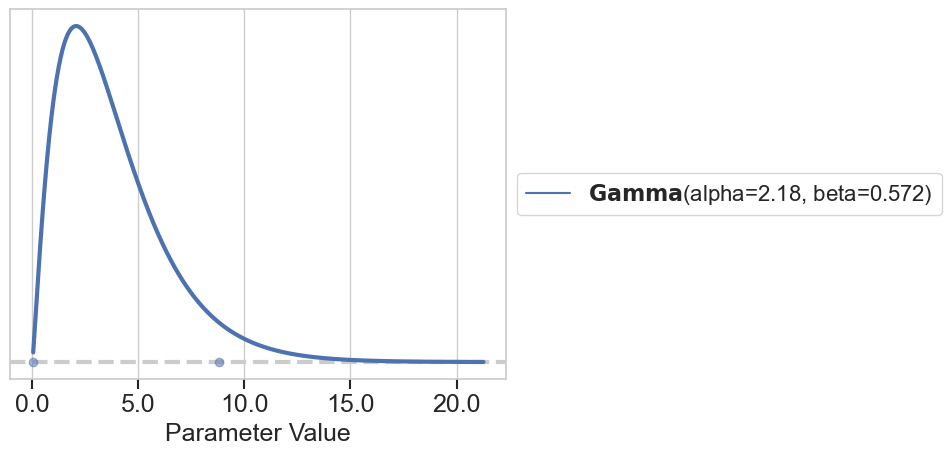

In [3]:
import preliz as pz
import numpy as np

dist = getattr(pz, "Gamma")()
result = pz.maxent(
    dist,
    lower=0.0081,
    upper=8.8,
    mass=0.95,
    plot=True,
    plot_kwargs={"color": "C0"})

ax = plt.gca()
for line in ax.lines:
    line.set_linewidth(3)
ax.tick_params(width=1.5, length=7)
ax.set_xlabel("Parameter Value", fontsize=18)
ax.set_xticklabels(np.round(ax.get_xticks(),2), fontsize=18)

/var/folders/41/tc0sn5mn46g26bhzv3slfbd80000gn/T/ipykernel_88811/1873384202.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.round(ax.get_xticks(),2), fontsize=18)


[Text(-0.2, 0, '-0.2'),
 Text(0.0, 0, '0.0'),
 Text(0.2, 0, '0.2'),
 Text(0.4000000000000001, 0, '0.4'),
 Text(0.6000000000000001, 0, '0.6'),
 Text(0.8, 0, '0.8')]

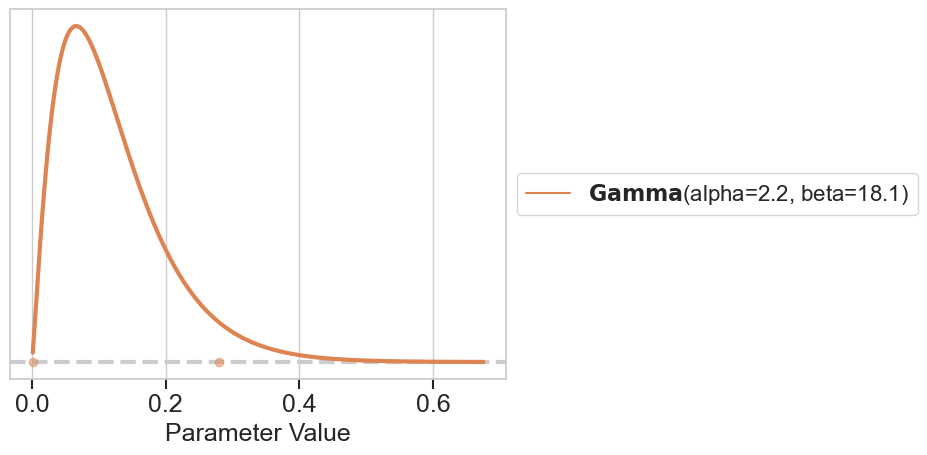

In [4]:
import preliz as pz
import numpy as np

dist2 = getattr(pz, "Gamma")()
result2 = pz.maxent(dist2,lower=0.00088, upper=0.28, mass=0.95, plot=True, plot_kwargs={"color": "C1"})

ax = plt.gca()
for line in ax.lines:
    line.set_linewidth(3)
ax.tick_params(width=1.5, length=7)
ax.set_xlabel("Parameter Value", fontsize=18)
ax.set_xticklabels(np.round(ax.get_xticks(),2), fontsize=18)